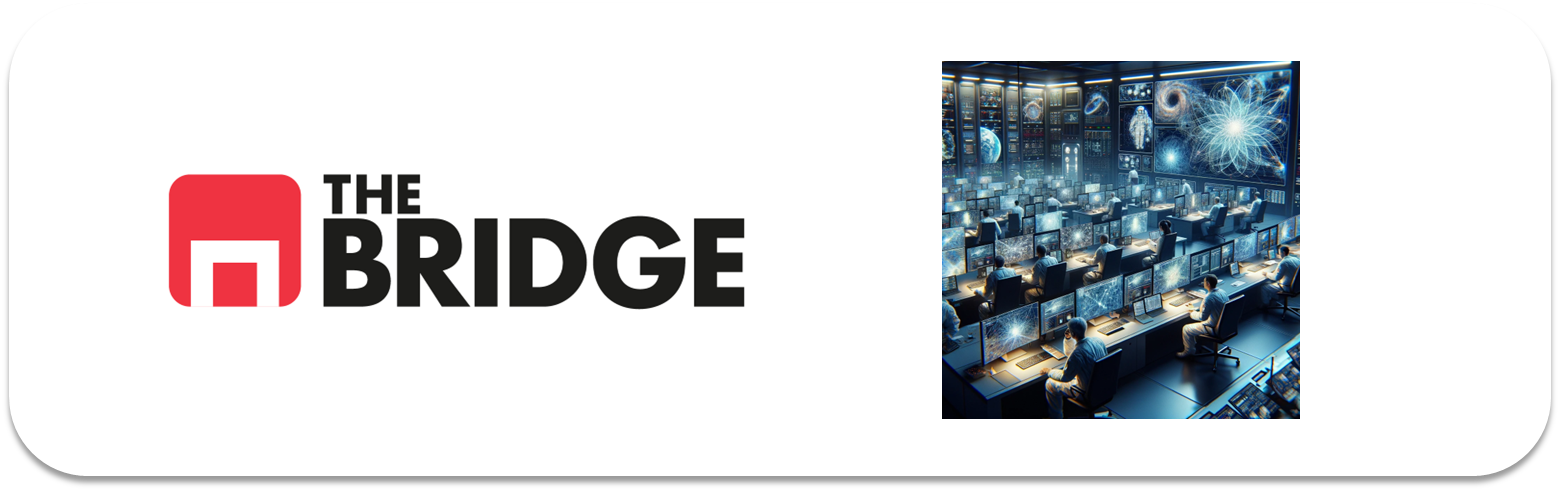

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [25]:
import cv2
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd
import seaborn as sns
from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import time
import gc

pd.options.mode.copy_on_write = True  # CoW por defecto a partir de pandas 3.0.0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_29844\722369965.py:15: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True  # CoW por defecto a partir de pandas 3.0.0


In [26]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.gpu_device_name())


Num GPUs Available:  0



In [2]:
def show_images_batch(pets, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, pet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(pet, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

def show_images_files(pets, names = [], n_cols = 5, size_scale = 2, train = True, indice = 0):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, filepet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)


In [31]:
TRAIN_PATH = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/seg_train/seg_train"
TEST_PATH = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/seg_test/seg_test"

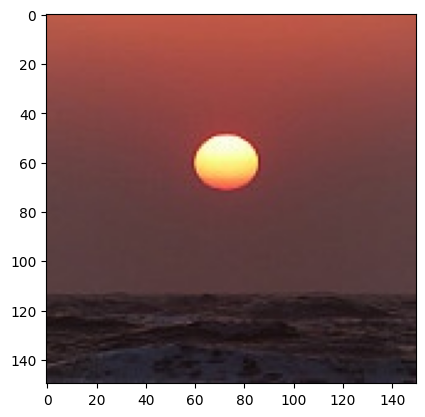

In [ ]:
plt.imshow(imread(TRAIN_PATH + "/sea/" + "11321.jpg"))
plt.show()

In [33]:
imread(TRAIN_PATH + "/sea/" + "11321.jpg").shape

(150, 150, 3)

In [35]:
IMG_WIDTH = IMG_HEIGHT = 75

In [36]:
def read_data(directorio, reshape_dim=(IMG_WIDTH, IMG_HEIGHT)):
    X = []
    y = []
    
    for folder in os.listdir(directorio):
        folder_path = os.path.join(directorio, folder)
        
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)
                
                # Redimensionamos las imágenes a 75x75
                img = cv2.resize(imread(file_path), reshape_dim)
                
                X.append(img)
                y.append(folder)
    
    return np.array(X), np.array(y)

In [37]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

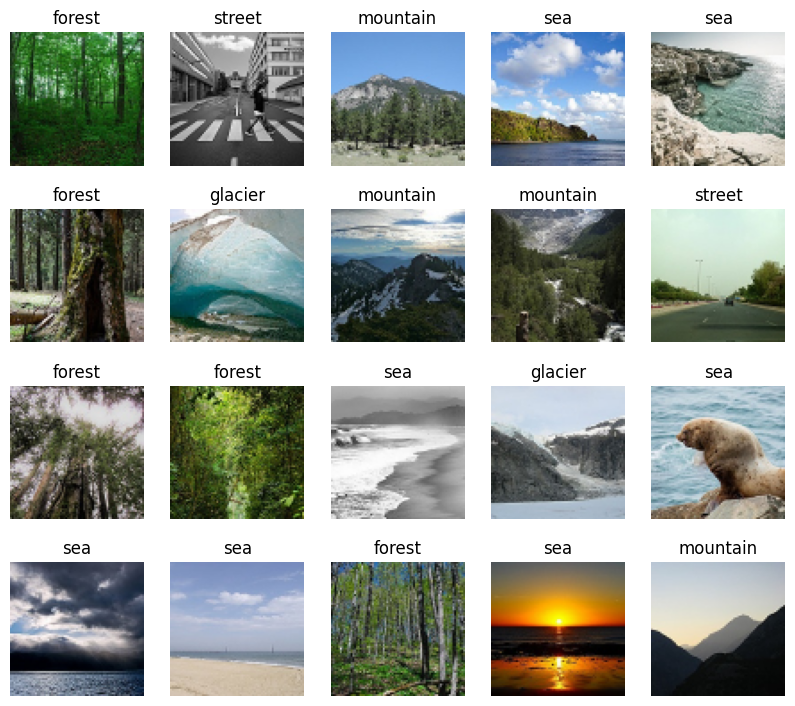

In [38]:
indices = np.random.randint(0, len(X_train), 20)
show_images_batch(X_train[indices], names = y_train[indices], n_cols = 5)


In [39]:
print(X_train.shape)
print(X_test.shape)

(14034, 75, 75, 3)
(3000, 75, 75, 3)


In [ ]:
# conjunto total del shape (14034*75*75*3)
X_train.size

236823750

In [ ]:
# Distribución de clases

pd.Series(y_train).value_counts(normalize=True)

mountain     0.178994
glacier      0.171298
street       0.169731
sea          0.162035
forest       0.161821
buildings    0.156121
Name: proportion, dtype: float64

In [ ]:
# vamos a utilizar InceptionV3, por lo tanto, en la documentación pone que el escalado está entre -1 y 1


In [ ]:
# Escalamos entre -1 y 1 porque Inception lo requiere

#from tensorflow.keras.layers import Rescaling, Input
#from tensorflow.keras import Model
#
#inputs = Input(shape=(224, 224, 3))
#x = Rescaling(scale=1./127.5, offset=-1)(inputs)
#x = base_model(x, training=False)

#outputs = todo lo anterior
#model = Model(inputs, outputs)


In [ ]:
# Escalamos entre -1 y 1 porque Inception lo requiere
X_train = (X_train/127.5) - 1.0
X_test = (X_test/127.5) - 1.0


In [ ]:
from keras.applications import InceptionV3

# Transfer Learning

Para el transfer learning vamos a usar una cabeza con una única capa densa con tantas unidades como el aplanamiento de las imágenes, es decir dependiendo de la resolución con la que hayamos cargado las imágenes al principio así tendremos una cantidad u otra de unidades

In [46]:
X_train.size

236823750

In [ ]:
temp_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(75, 75, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [47]:
temp_model.input

<KerasTensor shape=(None, 75, 75, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_110>

In [48]:
temp_model.output

<KerasTensor shape=(None, 1, 1, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_420>

In [49]:
IMG_WIDTH = IMG_HEIGHT = 75

# Cargamos el modelo pre-entrenado
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Congelamos sus capas
for layer in base_model.layers:
    layer.trainable = False

# Capa de aplanado de la salida del modelo base
def prepare_model(base_model = base_model): # Lo creamos así para poder reiniciar
    x = keras.layers.Flatten()(base_model.output)

    # Tantas unidades como el flatten de la salida de Inception -> 2048 features
    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)

    # Capa final de salida con 6 neuronas (una por clase) y activación softmax
    x = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, x)

    model.compile(
        optimizer = "adam",
        loss = "sparse_categorical_crossentropy", # sparse -> y es un array de es
        metrics = ['acc']
    )

    return model

# Observamos la arquitectura del modelo
model = prepare_model()
model.summary()


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 37, 37,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 35, 35,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 35, 35,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 17, 17,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 17, 17,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 15, 15,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 4,208,646 (16.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Para sacar el numero correcto de batch size, sacamos el 80 % del train 
# para multiplicarlo por 32

In [50]:
X_train.shape[0]*0.8

11227.2

In [51]:
instancias_train = len(X_train)

for i in range(1,5):
    print(f"Batch_size: {32*i}, num_steps_per_epoch: {round(instancias_train*0.8/(32*i))}")


Batch_size: 32, num_steps_per_epoch: 351
Batch_size: 64, num_steps_per_epoch: 175
Batch_size: 96, num_steps_per_epoch: 117
Batch_size: 128, num_steps_per_epoch: 88


In [52]:
y_train

array(['buildings', 'buildings', 'buildings', ..., 'street', 'street',
       'street'], shape=(14034,), dtype='<U9')

In [53]:
targets = pd.Series(y_train)

In [ ]:
# Reutilizando la serie que creamos para ver la distribución del target
mapa = {
    'mountain': 0,
    'street': 1,
    'buildings': 2,
    'sea': 3,
    'forest': 4,
    'glacier': 5
}

y_train_num = np.array([mapa[y] for y in y_train])
y_test_num = np.array([mapa[y] for y in y_test])


In [ ]:
y_train_num

In [ ]:
from sklearn.utils import shuffle
X_train_s, y_train_s = shuffle(X_train, y_train_num)


💡 shuffle() sin random_state — reproducibilidad no garantizada

A diferencia de la práctica de CNN con gatos/perros (donde validation_split sobre datos sin barajar producía un validation set roto), aquí sí se hace shuffle() antes de model.fit() con validation_split=0.2 — buena práctica, evita el problema de aquella práctica.

Pero shuffle(X_train, y_train_num) no tiene random_state fijado, así que el split resultante entre train/validation interno cambia en cada ejecución. No es un bug grave (los datos sí están barajados, así que no hay clases ausentes en validación), pero sí afecta a la reproducibilidad exacta de los números que aparecen en el texto.


In [ ]:
# from time import time

for batch_size in [32,64,96,128]:
    t_zero = time()
    model = prepare_model()
    model.fit(x_train,
              y_train_num,
              batch_size = batch_size,
              validation_split = 0.2,
              epochs = 1)
    tiempo = round(time() - t_zero, 3)

# del model
# gc.collect()

# print(f"batch_size: {batch_size}, num_steps: {len(x_train)/batch_size}, tiempo 1 epoca: {tiempo}, tiempo 20 épocas: {tiempo * 20}")


In [ ]:
batch_size = 128
earlyS = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)


In [ ]:
from time import time

t_zero = time()
model = prepare_model()
model.fit(X_train_s,
          y_train_s,
          batch_size = batch_size,
          validation_split = 0.2,
          epochs = 1,
          callbacks = [earlyS])


In [ ]:
model.evaluate(X_test, y_test_num)

In [ ]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test)]

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in mapa.items()}
y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]
print(classification_report(y_test_labels, y_pred_labels))


In [ ]:
# Bloque de limpieza
del model
del history
gc.collect()

# Fine-Tuning

In [ ]:
# 1 # Cargamos el modelo pre-entrenado
base_model = InceptionV3(include_top=False, weights="imagenet", input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# 4 # Congelamos sus capas
for layer in base_model.layers:
    layer.trainable = False

# 8 # Capa de flattenizado de la salida del modelo base
def prepare_model(base_model): # Lo creamos así para poder reinicializarlo en cada reentrenamiento en ejercicios posteriores
    x = keras.layers.Flatten()(base_model.output)

    # Tantas unidades como el flatten de la salida de Inception
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)

    # Capa final de salida con 6 neuronas (una por clase) y activación softmax
    x = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, x)

    model.compile(
        optimizer = "adam",
        loss = "sparse_categorical_crossentropy",
        metrics = ['acc']
    )

    return model


In [ ]:
ficheros = []
clases = []
for directorio in os.listdir(TRAIN_PATH):
    clase = directorio
    fichero = [TRAIN_PATH + directorio + "/" + fichero for fichero in os.listdir(TRAIN_PATH + directorio)]
    clases += [clase for fichero in fichero]
    ficheros += fichero
train_augmented = pd.DataFrame({"filename": ficheros, "category": clases})
train_augmented.head(10)
